# Ball Detection & Tracking — Data Preparation Pipeline

Import Libraries

In [1]:
import cv2
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn

Setup Data Paths — Local if available, otherwise Google Drive/Colab

In [2]:
LOCAL_DATASET_DIR = "Dataset/TrackNetV2"
LOCAL_FRAMES_DIR = "Dataset/TrackNetV2_extracted_frames"

USE_LOCAL_DATASET = os.path.isdir(LOCAL_DATASET_DIR)


def mount_drive():
    try:
        from google.colab import drive
    except ImportError:
        raise RuntimeError(
            "google.colab is not available (not running in Colab) and the "
            f"expected local folder was not found ('{LOCAL_DATASET_DIR}'). "
            "Add the local dataset folder, or run this notebook in Google Colab."
        )
    drive.mount('/content/drive')


if USE_LOCAL_DATASET:
    VIDEOS_DIR = LOCAL_DATASET_DIR
    # Frames follow the dataset: local dataset -> frames stay local too
    # (created fresh by the extraction cell below if not already present).
    FRAMES_BASE_OUTPUT = LOCAL_FRAMES_DIR
    print(f"Using local dataset: {VIDEOS_DIR}")
    print(f"Using local frames folder: {FRAMES_BASE_OUTPUT}")
else:
    mount_drive()
    VIDEOS_DIR = "/content/TrackNetV2/TrackNetV2/"
    FRAMES_BASE_OUTPUT = "/content/drive/MyDrive/TrackNetV2_extracted_frames"
    print(f"Local dataset folder not found — using Google Drive/Colab: {VIDEOS_DIR}")
    print(f"Using Google Drive/Colab frames folder: {FRAMES_BASE_OUTPUT}")

Using local dataset: Dataset/TrackNetV2
Using local frames folder: Dataset/TrackNetV2_extracted_frames


Loading & Extracting the Data

In [3]:
if not USE_LOCAL_DATASET:
    !find /content/drive/MyDrive -iname "*TrackNetV2*"
    !unzip -q "/content/drive/MyDrive/TrackNetV2.zip" -d /content/TrackNetV2
else:
    print(f"Using local dataset at '{VIDEOS_DIR}' — skipping Drive search/unzip.")

Using local dataset at 'Dataset/TrackNetV2' — skipping Drive search/unzip.


In [4]:
MAX_DEPTH = 4
base_depth = VIDEOS_DIR.rstrip(os.sep).count(os.sep)
printed = 0
for dirpath, dirnames, filenames in os.walk(VIDEOS_DIR):
    depth = dirpath.rstrip(os.sep).count(os.sep) - base_depth
    if depth >= MAX_DEPTH:
        dirnames[:] = []
        continue
    print(dirpath)
    printed += 1
    if printed >= 30:
        break

Dataset/TrackNetV2
Dataset/TrackNetV2\Amateur
Dataset/TrackNetV2\Amateur\match1
Dataset/TrackNetV2\Amateur\match1\csv
Dataset/TrackNetV2\Amateur\match1\video
Dataset/TrackNetV2\Amateur\match2
Dataset/TrackNetV2\Amateur\match2\csv
Dataset/TrackNetV2\Amateur\match2\video
Dataset/TrackNetV2\Amateur\match3
Dataset/TrackNetV2\Amateur\match3\csv
Dataset/TrackNetV2\Amateur\match3\video
Dataset/TrackNetV2\Professional
Dataset/TrackNetV2\Professional\match1
Dataset/TrackNetV2\Professional\match1\csv
Dataset/TrackNetV2\Professional\match1\video
Dataset/TrackNetV2\Professional\match10
Dataset/TrackNetV2\Professional\match10\csv
Dataset/TrackNetV2\Professional\match10\video
Dataset/TrackNetV2\Professional\match11
Dataset/TrackNetV2\Professional\match11\csv
Dataset/TrackNetV2\Professional\match11\video
Dataset/TrackNetV2\Professional\match12
Dataset/TrackNetV2\Professional\match12\csv
Dataset/TrackNetV2\Professional\match12\video
Dataset/TrackNetV2\Professional\match13
Dataset/TrackNetV2\Profession

Inspect Labels

In [5]:
LABEL_DIR = os.path.join(VIDEOS_DIR, "Amateur", "match1", "csv", "1_00_01_ball.csv")
label = pd.read_csv(LABEL_DIR)
label.head(20)

,Frame,Visibility,X,Y
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0
5,5,0,0,0
6,6,0,0,0
7,7,0,0,0
8,8,0,0,0
9,9,0,0,0


In [6]:
print(label['Visibility'].unique())
print(label.columns.tolist())

[0 1]
['Frame', 'Visibility', 'X', 'Y']


Inspect Video Properties

In [7]:
IMG_PATH = os.path.join(VIDEOS_DIR, "Amateur", "match1", "video", "1_00_01.mp4")
video = cv2.VideoCapture(IMG_PATH)
if not video.isOpened():
    print("Error: Could not open video.")
else:
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    fps    = video.get(cv2.CAP_PROP_FPS)
    print(f"Resolution : {width} X {height}")
    print(f"FPS:         {fps}")

Resolution : 1280 X 720
FPS:         30.0


In [8]:
video_dir = os.path.join(VIDEOS_DIR, "Amateur", "match1", "video")
csv_dir = os.path.join(VIDEOS_DIR, "Amateur", "match1", "csv")
print(*sorted(os.listdir(video_dir)), sep="\n")
print()
print(*sorted(os.listdir(csv_dir)), sep="\n")

1_00_01.mp4
1_01_01.mp4
1_01_02.mp4
1_01_03.mp4
1_01_04.mp4
1_02_04.mp4
1_03_04.mp4
1_03_05.mp4
1_04_05.mp4
1_05_05.mp4

1_00_01_ball.csv
1_01_01_ball.csv
1_01_02_ball.csv
1_01_03_ball.csv
1_01_04_ball.csv
1_02_04_ball.csv
1_03_04_ball.csv
1_03_05_ball.csv
1_04_05_ball.csv
1_05_05_ball.csv


Extract Frames from Videos

In [9]:
def extract_frames(video_path, output_dir):
  os.makedirs(output_dir, exist_ok=True)

  # Check if frames are already extracted
  existing_frames = [f for f in os.listdir(output_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  if existing_frames:
      print(f"Frames already exist in {output_dir}. Skipping extraction.")
      return len(existing_frames)

  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
      print(f"Error: Could not open video {video_path}")
      return 0

  print(f"Extracting frames from: {video_path} to {output_dir}")
  i = 0
  while True:
    ret, frame = cap.read()
    if not ret:
      break
    cv2.imwrite(os.path.join(output_dir, f"frame_{i:05d}.jpg"), frame)
    i += 1
  cap.release()
  print(f"Extracted {i} frames.")
  return i

for dirpath, dirnames, filenames in os.walk(VIDEOS_DIR):
  for filename in filenames:
    if filename.endswith(".mp4"):
      video_file_path = os.path.join(dirpath, filename)
      relative_path = os.path.relpath(video_file_path, VIDEOS_DIR)
      video_output_dir = os.path.join(FRAMES_BASE_OUTPUT, os.path.dirname(relative_path), os.path.splitext(filename)[0])

      extract_frames(video_file_path, video_output_dir)

Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_00_01. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_01_01. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_01_02. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_01_03. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_01_04. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_02_04. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_03_04. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_03_05. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Amateur\match1\video\1_04_05. Skipping extraction.
F

Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match4\video\3_07_05. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match4\video\3_18_17. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\1_01_01. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\1_01_02. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\1_19_18. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\1_21_19. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\2_15_13. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional\match5\video\2_20_17. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Professional

Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_05_02. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_05_03. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_06_03. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_07_03. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_07_04. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_07_06. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_09_06. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\1_09_07. Skipping extraction.
Frames already exist in Dataset/TrackNetV2_extracted_frames\Test\match1\video\2_02_07. Skipping extraction.
Frames already exist in Data

Build Sliding-Window Frame Triplets (Truncated to CSV Length)

In [10]:
WINDOW_SIZE = 3

samples = []

for dirpath, dirnames, filenames in os.walk(FRAMES_BASE_OUTPUT):
    if dirnames:
        continue

    frame_files = sorted(f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png")))
    if not frame_files:
        continue

    rel_path = os.path.relpath(dirpath, FRAMES_BASE_OUTPUT)
    parts = rel_path.split(os.sep)
    clip_name = parts[-1]
    csv_parts = ["csv" if p == "video" else p for p in parts[:-1]]
    csv_path = os.path.join(VIDEOS_DIR, *csv_parts, f"{clip_name}_ball.csv")

    if not os.path.exists(csv_path):
        continue

    clip_labels = pd.read_csv(csv_path)

    n = len(clip_labels)
    frame_paths = [os.path.join(dirpath, f) for f in frame_files[:n]]

    for i in range(len(frame_paths) - WINDOW_SIZE + 1):
        frame_path_1, frame_path_2, frame_path_3 = frame_paths[i], frame_paths[i + 1], frame_paths[i + 2]
        label_1 = tuple(clip_labels.iloc[i][["Visibility", "X", "Y"]])
        label_2 = tuple(clip_labels.iloc[i + 1][["Visibility", "X", "Y"]])
        label_3 = tuple(clip_labels.iloc[i + 2][["Visibility", "X", "Y"]])
        samples.append((frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3))

print(f"Built {len(samples)} sliding-window triplets from {FRAMES_BASE_OUTPUT}")

Built 90583 sliding-window triplets from Dataset/TrackNetV2_extracted_frames


In [11]:
class TrackNetDataset(torch.utils.data.Dataset):
    def __init__(self, samples, resize_to=(512, 288)):
      self.samples = samples
      self.resize_to = resize_to

    def __len__(self):
      return len(self.samples)

    def __getitem__(self, idx):
      frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3 = self.samples[idx]

      new_w, new_h = self.resize_to
      images = []
      labels = []
      for frame_path, label in zip((frame_path_1, frame_path_2, frame_path_3), (label_1, label_2, label_3)):
        image = cv2.imread(frame_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = cv2.resize(image, self.resize_to, interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        images.append(image.transpose(2, 0, 1))

        visibility, x, y = label
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        labels.append((visibility, x * scale_x, y * scale_y))

      images = np.concatenate(images, axis=0)
      labels = np.array(labels, dtype=np.float32)

      return torch.from_numpy(images), torch.from_numpy(labels)

In [12]:
from matplotlib import pyplot as plt

dataset = TrackNetDataset(samples)
images, labels = dataset[15]


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([9, 288, 512])
Labels shape: torch.Size([3, 3])


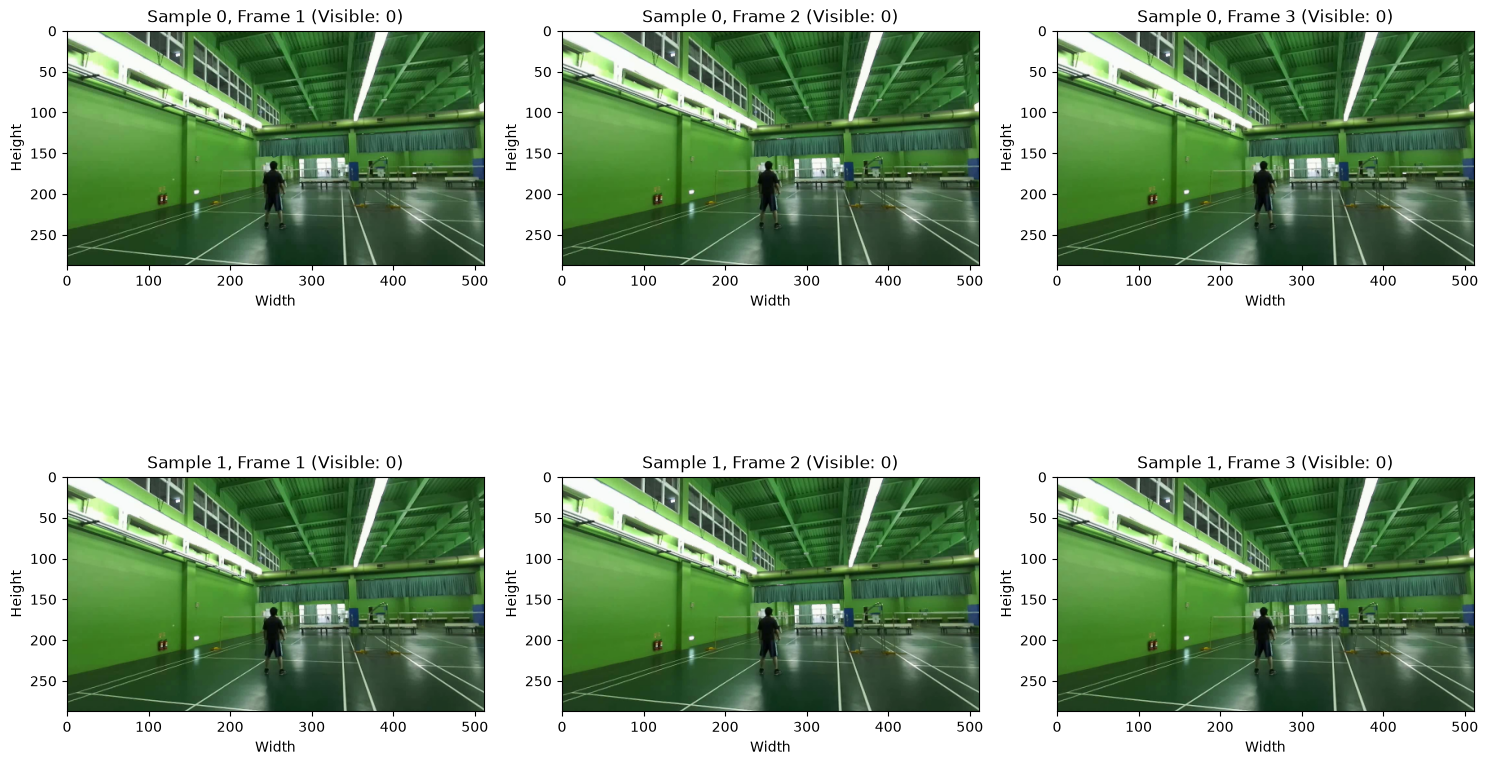

In [13]:
import math

cols = 3
num_samples_to_fetch = 2
total_frames_to_plot = num_samples_to_fetch * 3
rows = math.ceil(total_frames_to_plot / cols)
plt.figure(figsize=(cols * 5, rows * 5))

frame_counter = 0
for sample_idx in range(num_samples_to_fetch):
    if sample_idx >= len(dataset):
        print(f"Warning: Dataset only has {len(dataset)} samples. Plotting fewer than requested.")
        break

    images_from_sample, labels_from_sample = dataset[sample_idx]

    for i in range(3):
        if frame_counter >= total_frames_to_plot:
            break

        img_to_show = images_from_sample[i*3:(i*3)+3].permute(1, 2, 0).numpy()
        visibility, x, y = labels_from_sample[i].tolist()

        plt.subplot(rows, cols, frame_counter + 1)
        plt.imshow(img_to_show)
        plt.title(f"Sample {sample_idx}, Frame {i+1} (Visible: {int(visibility)})")
        plt.xlabel("Width")
        plt.ylabel("Height")


        if visibility == 1:
            plt.scatter(x, y, color='red', marker='o', s=100, edgecolors='white', linewidth=1, label=f'Shuttlecock position ({int(x)}, {int(y)})')
            plt.legend(loc='upper right')

        frame_counter += 1
    if frame_counter >= total_frames_to_plot:
        break

plt.tight_layout()
plt.show()

Generate Gaussian Heatmaps for Ball Position

In [14]:
HEATMAP_SIGMA = 5

def generate_heatmap(x, y, visibility, H, W, sigma=HEATMAP_SIGMA):
    if not visibility:
        return np.zeros((H, W), dtype=np.float32)

    cols, rows = np.meshgrid(np.arange(W), np.arange(H))
    heatmap = np.exp(-((cols - x) ** 2 + (rows - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)

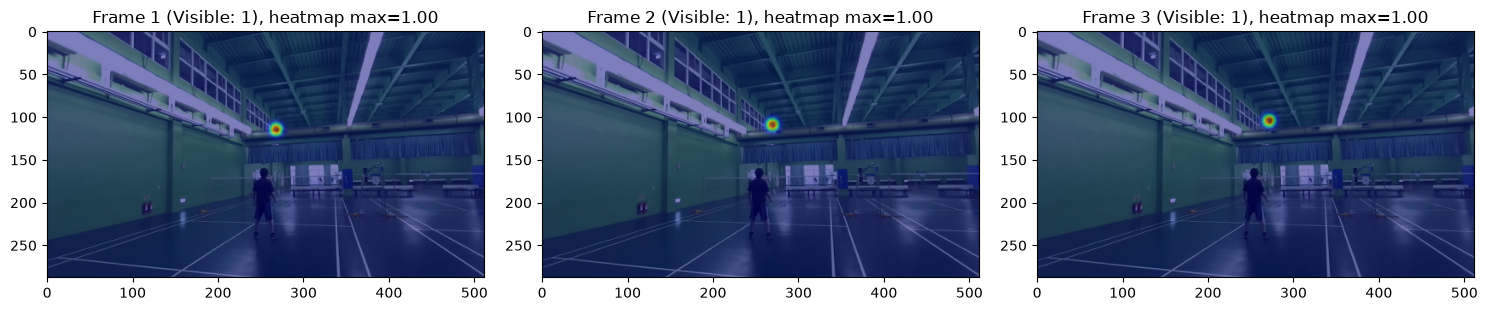

In [15]:
images, labels = dataset[15]
H, W = dataset.resize_to[1], dataset.resize_to[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    visibility, x, y = labels[i].tolist()
    heatmap = generate_heatmap(x, y, visibility, H, W)

    img_to_show = images[i*3:(i*3)+3].permute(1, 2, 0).numpy()
    ax.imshow(img_to_show)
    ax.imshow(heatmap, cmap='jet', alpha=0.5)
    ax.set_title(f"Frame {i+1} (Visible: {int(visibility)}), heatmap max={heatmap.max():.2f}")

plt.tight_layout()
plt.show()

VGG-Style Encoder-Decoder (TrackNetV2)

In [ ]:
class TrackNetV2(nn.Module):
    def __init__(self):
        super().__init__()

        # ---- Encoder ----
        # Each block split into conv-layers and pool separately,
        # so we can grab the pre-pool output for skip connections.
        # BatchNorm after every conv (matching the original TrackNetV2 paper)
        # speeds up and stabilizes convergence when training from scratch.
        self.enc1_conv = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc2_conv = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2, 2)

        self.enc3_conv = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2, 2)

        self.enc4_conv = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        self.pool4 = nn.MaxPool2d(2, 2)

        # ---- Decoder ----
        # dec*_conv in_channels = upsampled channels + concatenated skip channels
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1_conv = nn.Sequential(
            nn.Conv2d(768, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),  # 256 (up1) + 512 (e4 skip)
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2_conv = nn.Sequential(
            nn.Conv2d(384, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),  # 128 (up2) + 256 (e3 skip)
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3_conv = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),  # 64 (up3) + 128 (e2 skip)
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )

        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        # Raw logits — no activation. Loss is BCEWithLogitsLoss, which applies
        # sigmoid internally (more numerically stable than a separate Sigmoid + BCE).
        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        # Encoder — keep pre-pool outputs for skip connections
        e1 = self.enc1_conv(x)          # (64, 288, 512)
        p1 = self.pool1(e1)             # (64, 144, 256)

        e2 = self.enc2_conv(p1)         # (128, 144, 256)
        p2 = self.pool2(e2)             # (128, 72, 128)

        e3 = self.enc3_conv(p2)         # (256, 72, 128)
        p3 = self.pool3(e3)             # (256, 36, 64)

        e4 = self.enc4_conv(p3)         # (512, 36, 64)
        p4 = self.pool4(e4)             # (512, 18, 32)  <- bottleneck

        # Decoder — upsample, concat with matching skip, conv
        d1 = self.up1(p4)                          # (256, 36, 64)
        d1 = torch.cat([d1, e4], dim=1)             # (768, 36, 64)
        d1 = self.dec1_conv(d1)                     # (256, 36, 64)

        d2 = self.up2(d1)                           # (128, 72, 128)
        d2 = torch.cat([d2, e3], dim=1)             # (384, 72, 128)
        d2 = self.dec2_conv(d2)                     # (128, 72, 128)

        d3 = self.up3(d2)                           # (64, 144, 256)
        d3 = torch.cat([d3, e2], dim=1)             # (192, 144, 256)
        d3 = self.dec3_conv(d3)                     # (64, 144, 256)

        d4 = self.up4(d3)                           # (32, 288, 512)
        out = self.final_conv(d4)                   # (3, 288, 512) raw logits

        return out

Heatmap Target Wrapper — pairs each triplet's images with its 3-channel Gaussian heatmap target

In [17]:
class TrackNetHeatmapDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.W, self.H = base_dataset.resize_to

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        images, labels = self.base_dataset[idx]

        heatmaps = np.stack([
            generate_heatmap(x=labels[i, 1].item(), y=labels[i, 2].item(),
                              visibility=labels[i, 0].item(), H=self.H, W=self.W)
            for i in range(labels.shape[0])
        ], axis=0)

        return images.float(), torch.from_numpy(heatmaps)


heatmap_dataset = TrackNetHeatmapDataset(dataset)
sample_images, sample_targets = heatmap_dataset[15]
print(f"Images shape:  {sample_images.shape}")
print(f"Targets shape: {sample_targets.shape}, max={sample_targets.max():.2f}")

Images shape:  torch.Size([9, 288, 512])
Targets shape: torch.Size([3, 288, 512]), max=1.00


Model, Weighted BCE Loss, Optimizer, Tiny Overfit Subset

In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cpu":
    print(
        "WARNING: training on CPU — no CUDA device detected by PyTorch. "
        "If you have an NVIDIA GPU, make sure you installed a CUDA build of "
        "PyTorch (not the '+cpu' wheel), e.g.:\n"
        "  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124"
    )
else:
    print(f"Using GPU: {torch.cuda.get_device_name(DEVICE)}")

model = TrackNetV2().to(DEVICE)

# Gaussian blobs (sigma=5) cover a small fraction of the 288x512 frame, so
# background pixels vastly outnumber ball pixels. pos_weight upweights the
# positive term of BCE to counter that imbalance. BCEWithLogitsLoss works
# fine against our continuous 0->1 Gaussian targets, not just hard 0/1 labels.
POS_WEIGHT = 10.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Tiny subset to sanity-check the model/loss/optimizer can overfit before
# committing to a full training run.
subset_indices = list(range(15, 30))
train_subset = torch.utils.data.Subset(heatmap_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=4, shuffle=True)

print(f"Device: {DEVICE}")
print(f"Subset size: {len(train_subset)}")

Using GPU: NVIDIA GeForce RTX 2050


Device: cuda
Subset size: 15


In [19]:
print(model.final_conv)

Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))


Training Loop — Overfit Sanity Check on the Tiny Subset

In [20]:
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 5

best_loss = float('inf')
patience_counter = 0

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {avg_epoch_loss:.4f}")

    # Early stopping logic
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter > EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after {epoch + 1} epochs due to no improvement in loss for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        break

Epoch 1/200 - Loss: 0.6278


Epoch 2/200 - Loss: 1.0708


Epoch 3/200 - Loss: 0.5347


Epoch 4/200 - Loss: 0.5618


Epoch 5/200 - Loss: 0.3296


...

Epoch 41/200 - Loss: 0.0434


Epoch 42/200 - Loss: 0.0439


Epoch 43/200 - Loss: 0.0269


Epoch 44/200 - Loss: 0.0488


Epoch 45/200 - Loss: 0.0575
Early stopping after 45 epochs due to no improvement in loss for 5 consecutive epochs.


In [21]:
model = TrackNetV2().to(DEVICE)
x = torch.randn(1, 9, 288, 512).to(DEVICE)
out = model(x)
print(out.shape)

torch.Size([1, 3, 288, 512])


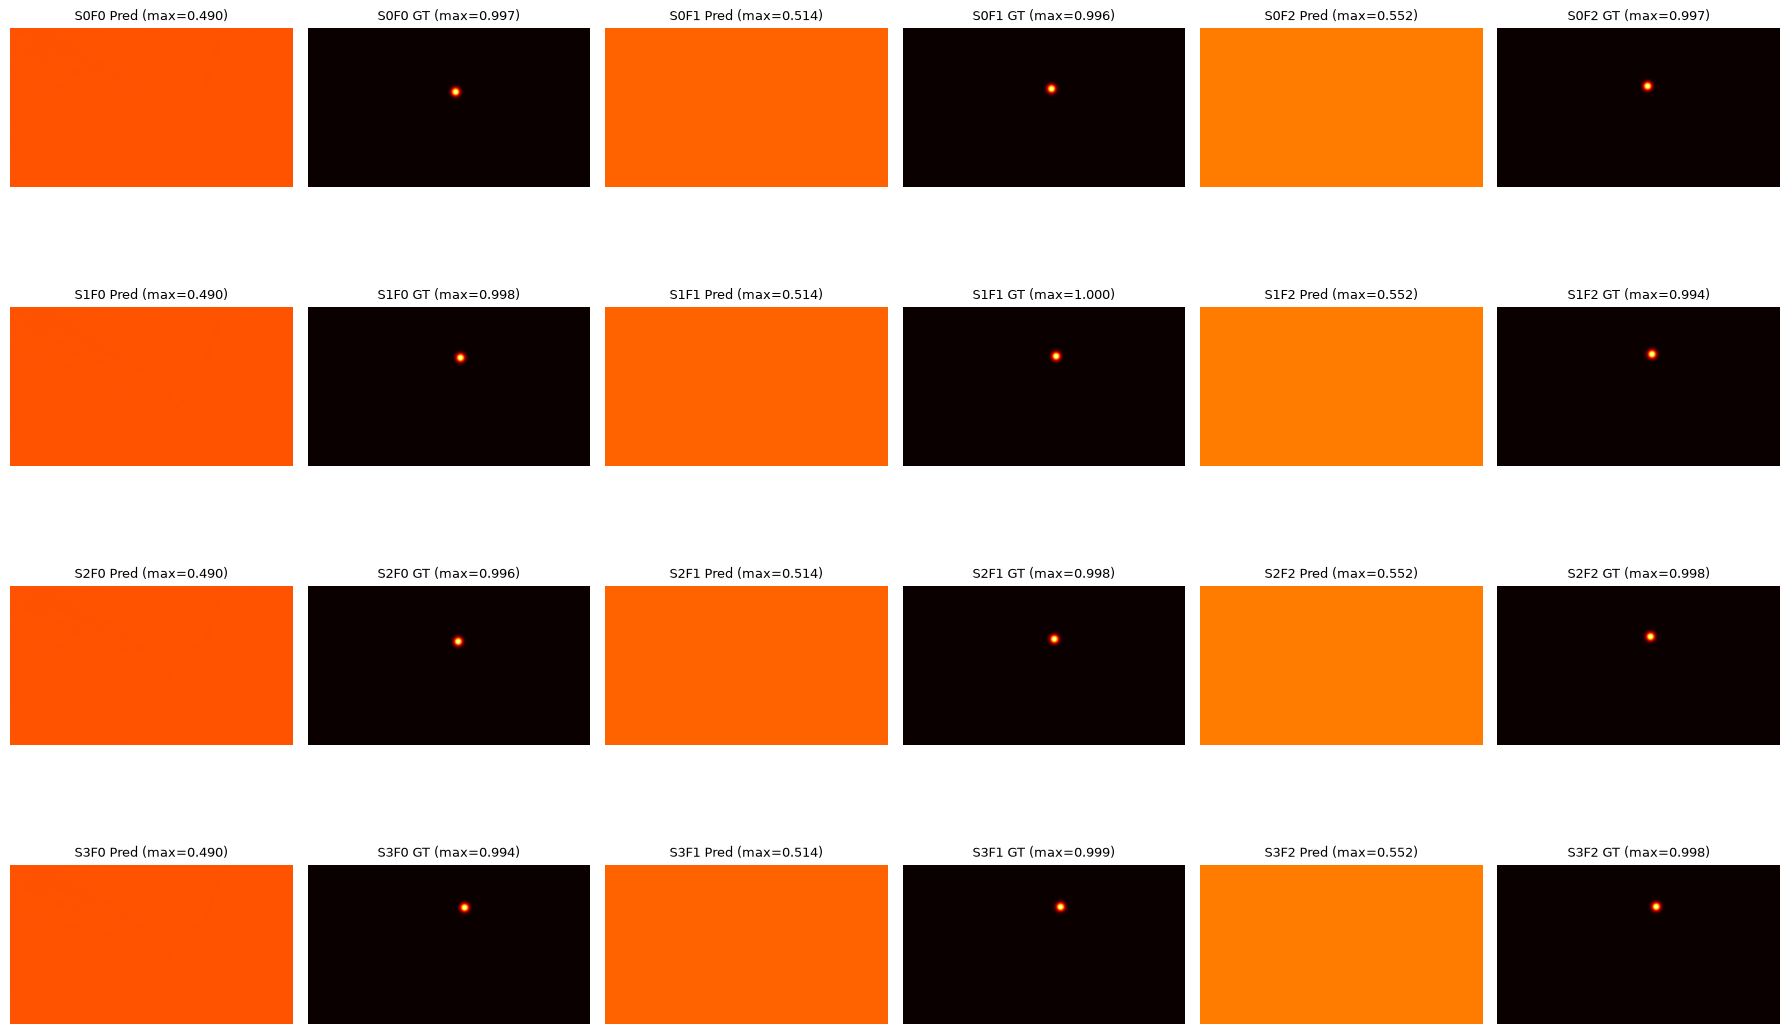

In [22]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))
    images = images.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)  # apply sigmoid manually now, since it's not in the model anymore

n_samples = preds.shape[0]
n_frames = preds.shape[1]

fig, axes = plt.subplots(n_samples, n_frames * 2, figsize=(n_frames * 2 * 3, n_samples * 3))

for s in range(n_samples):
    for f in range(n_frames):
        pred_heatmap = preds[s, f].cpu().numpy()
        target_heatmap = targets[s, f].cpu().numpy()

        ax_pred = axes[s, f * 2]
        ax_gt = axes[s, f * 2 + 1]

        ax_pred.imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_pred.set_title(f"S{s}F{f} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        ax_pred.axis('off')

        ax_gt.imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_gt.set_title(f"S{s}F{f} GT (max={target_heatmap.max():.3f})", fontsize=9)
        ax_gt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))
    images = images.to(DEVICE)
    targets = targets.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)

print("=== Overall prediction stats ===")
print(f"mean={preds.mean().item():.6f}  std={preds.std().item():.6f}  "
      f"min={preds.min().item():.6f}  max={preds.max().item():.6f}")

print("\n=== Overall logit stats (pre-sigmoid) ===")
print(f"mean={logits.mean().item():.6f}  std={logits.std().item():.6f}  "
      f"min={logits.min().item():.6f}  max={logits.max().item():.6f}")

print("\n=== Per-sample, per-frame: pred-at-ball vs pred-background-mean ===")
for s in range(preds.shape[0]):
    for f in range(preds.shape[1]):
        t = targets[s, f]
        p = preds[s, f]
        gt_max = t.max().item()
        if gt_max > 0.5:
            iy, ix = np.unravel_index(t.argmax().cpu().numpy(), t.shape)
            pred_at_ball = p[iy, ix].item()
        else:
            pred_at_ball = float('nan')
        bg_mask = t < 0.01
        pred_bg_mean = p[bg_mask].mean().item()
        pred_bg_std = p[bg_mask].std().item()
        print(f"S{s}F{f}: gt_max={gt_max:.3f}  pred_at_ball={pred_at_ball:.4f}  "
              f"pred_bg_mean={pred_bg_mean:.4f}  pred_bg_std={pred_bg_std:.4f}")

recomputed_loss = criterion(logits, targets)
print(f"\nRecomputed BCEWithLogitsLoss on this exact live batch: {recomputed_loss.item():.6f}")

# manual sanity-check of BCEWithLogits math on the background-only region, no pos_weight involved
bg_mask_full = targets < 0.01
manual_bg_loss = torch.nn.functional.binary_cross_entropy_with_logits(
    logits[bg_mask_full], targets[bg_mask_full], reduction='mean'
)
print(f"Manual BCE loss restricted to background-only pixels: {manual_bg_loss.item():.6f}")
print(f"Fraction of pixels counted as background (target<0.01): {bg_mask_full.float().mean().item():.6f}")


=== Overall prediction stats ===
mean=0.517263  std=0.025476  min=0.487792  max=0.551975

=== Overall logit stats (pre-sigmoid) ===
mean=0.069284  std=0.102207  min=-0.048843  max=0.208653

=== Per-sample, per-frame: pred-at-ball vs pred-background-mean ===
S0F0: gt_max=0.998  pred_at_ball=0.4880  pred_bg_mean=0.4886  pred_bg_std=0.0005
S0F1: gt_max=0.999  pred_at_ball=0.5119  pred_bg_mean=0.5127  pred_bg_std=0.0006
S0F2: gt_max=0.998  pred_at_ball=0.5514  pred_bg_mean=0.5505  pred_bg_std=0.0009
S1F0: gt_max=0.998  pred_at_ball=0.4881  pred_bg_mean=0.4886  pred_bg_std=0.0005
S1F1: gt_max=0.998  pred_at_ball=0.5128  pred_bg_mean=0.5127  pred_bg_std=0.0006
S1F2: gt_max=1.000  pred_at_ball=0.5506  pred_bg_mean=0.5505  pred_bg_std=0.0009
S2F0: gt_max=0.994  pred_at_ball=0.4893  pred_bg_mean=0.4886  pred_bg_std=0.0005
S2F1: gt_max=0.999  pred_at_ball=0.5119  pred_bg_mean=0.5127  pred_bg_std=0.0006
S2F2: gt_max=0.998  pred_at_ball=0.5515  pred_bg_mean=0.5505  pred_bg_std=0.0009
S3F0: gt_max=

Total dataset size: 90583
Probing indices spread across full dataset: [0, 12940, 25880, 38820, 51761, 64701, 77641, 90582]


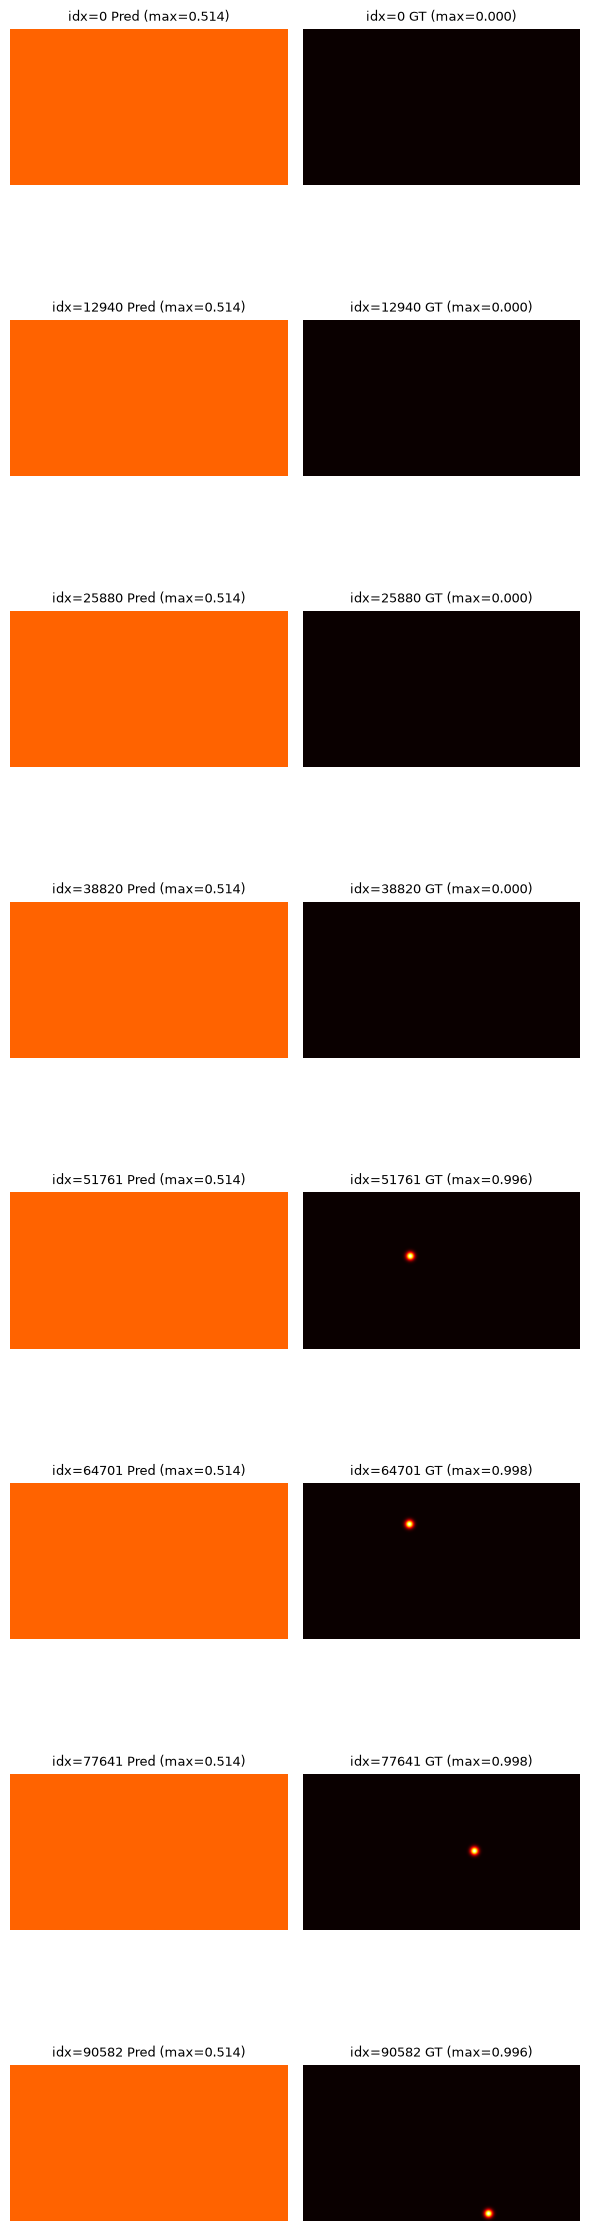

In [24]:
print(f"Total dataset size: {len(heatmap_dataset)}")

n_probe = 8
probe_indices = np.linspace(0, len(heatmap_dataset) - 1, n_probe).astype(int).tolist()
print(f"Probing indices spread across full dataset: {probe_indices}")

frame_idx = 1  # middle frame of each triplet

model.eval()
fig, axes = plt.subplots(n_probe, 2, figsize=(6, n_probe * 3))

with torch.no_grad():
    for row, idx in enumerate(probe_indices):
        images, targets = heatmap_dataset[idx]
        images = images.unsqueeze(0).to(DEVICE)
        logits = model(images)
        preds = torch.sigmoid(logits)

        pred_heatmap = preds[0, frame_idx].cpu().numpy()
        target_heatmap = targets[frame_idx].numpy()

        ax_pred = axes[row, 0]
        ax_gt = axes[row, 1]

        ax_pred.imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_pred.set_title(f"idx={idx} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        ax_pred.axis('off')

        ax_gt.imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_gt.set_title(f"idx={idx} GT (max={target_heatmap.max():.3f})", fontsize=9)
        ax_gt.axis('off')

plt.tight_layout()
plt.show()

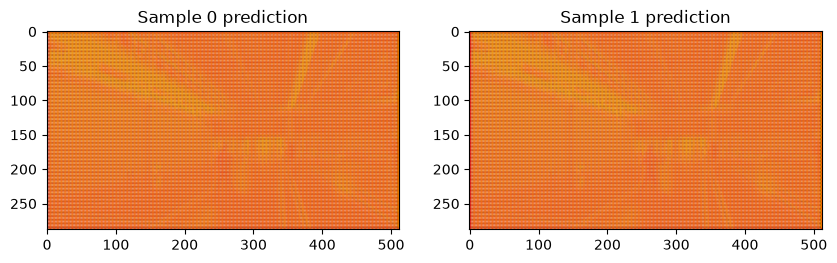

In [25]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))  # fresh batch, not reused from earlier cells
    images = images.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)

# compare predicted heatmaps for sample 0 vs sample 1 (different ball locations)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(preds[0, 1].cpu().numpy(), cmap='hot')
axes[0].set_title("Sample 0 prediction")
axes[1].imshow(preds[1, 1].cpu().numpy(), cmap='hot')
axes[1].set_title("Sample 1 prediction")
plt.show()

## Real Training — Diverse Multi-Clip Subset (Train/Val Split by Clip)

The overfit sanity check above only ever saw 15 consecutive frames from one clip, which is why it failed to generalize. This section splits the full dataset by *clip* (not by frame) so train and validation never share a video, samples a diverse subset across many clips, and trains/evaluates properly.

In [ ]:
import random

def get_clip_id(sample):
    frame_path_1 = sample[0]
    return os.path.normpath(os.path.dirname(frame_path_1))

clip_ids = [get_clip_id(s) for s in samples]
unique_clips = sorted(set(clip_ids))
print(f"Total samples: {len(samples)}, unique clips: {len(unique_clips)}")

rng = random.Random(42)
shuffled_clips = unique_clips[:]
rng.shuffle(shuffled_clips)

VAL_FRACTION = 0.2
n_val_clips = max(1, int(len(shuffled_clips) * VAL_FRACTION))
val_clips = set(shuffled_clips[:n_val_clips])
train_clips = set(shuffled_clips[n_val_clips:])

train_indices_all = [i for i, cid in enumerate(clip_ids) if cid in train_clips]
val_indices_all = [i for i, cid in enumerate(clip_ids) if cid in val_clips]

print(f"Train clips: {len(train_clips)}, samples available: {len(train_indices_all)}")
print(f"Val clips:   {len(val_clips)}, samples available: {len(val_indices_all)}")

rng.shuffle(train_indices_all)
rng.shuffle(val_indices_all)
# Use every available sample instead of a small fixed-size cap — the earlier
# 600/150-sample run was a pipeline smoke test, not a real training budget.
train_indices = train_indices_all
val_indices = val_indices_all

print(f"\nUsing {len(train_indices)} train samples from "
      f"{len(set(clip_ids[i] for i in train_indices))} distinct clips")
print(f"Using {len(val_indices)} val samples from "
      f"{len(set(clip_ids[i] for i in val_indices))} distinct clips (held out, no overlap with train clips)")

# Benchmarked on this GPU (RTX 2050, 4GB VRAM): with BatchNorm added, batch
# sizes above 8 (without mixed precision) overflow VRAM and silently spill
# into slow shared system memory (~4s/step instead of ~0.5s/step). Batch 8
# + AMP (enabled in the training loop below) fits comfortably (~3.3GB peak).
BATCH_SIZE = 8
train_subset_full = torch.utils.data.Subset(heatmap_dataset, train_indices)
val_subset_full = torch.utils.data.Subset(heatmap_dataset, val_indices)

# num_workers=0: on Windows, DataLoader workers use spawn multiprocessing,
# which can't pickle classes (TrackNetHeatmapDataset) defined live inside a
# Jupyter kernel's __main__ — workers crash immediately with an
# AttributeError. Single-process loading is plenty fast here anyway: the
# GPU compute step (~0.5s/batch) is the bottleneck, not disk I/O.
full_train_loader = torch.utils.data.DataLoader(
    train_subset_full, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
)
full_val_loader = torch.utils.data.DataLoader(
    val_subset_full, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)

In [ ]:
# Fresh model + optimizer + criterion, created together in one cell so the
# optimizer can never end up bound to a stale/orphaned model instance.
model = TrackNetV2().to(DEVICE)

# Gaussian blobs (sigma=5) cover under ~0.5% of the 288x512 frame's pixels.
# pos_weight=10 (used in the smoke-test run above) barely counters that —
# raised substantially so ball pixels actually drive the gradient instead of
# being drowned out by background.
POS_WEIGHT = 200.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

# Mixed precision: keeps peak VRAM under the RTX 2050's 4GB budget at
# batch_size=8 with the BatchNorm-enabled model (benchmarked ~3.3GB vs
# ~6.25GB without AMP, which overflows VRAM and silently falls back to slow
# shared system memory).
USE_AMP = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print("Fresh model/optimizer/criterion/scheduler/scaler created together.")
print(f"AMP enabled: {USE_AMP}")

In [ ]:
import sys
names = ["model", "optimizer", "criterion", "scheduler", "scaler", "full_train_loader", "full_val_loader",
         "train_subset_full", "val_subset_full", "train_indices", "val_indices", "DEVICE"]
for n in names:
    print(n, "->", "OK" if n in globals() else "MISSING")
print("\nCUDA available:", torch.cuda.is_available())
print("Model device:", next(model.parameters()).device if "model" in globals() else "N/A")

In [ ]:
import copy
import time

NUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2
history = {"train_loss": [], "val_loss": []}
best_val_loss = float('inf')
best_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    for images, targets in full_train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_subset_full)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, targets in full_val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, targets)
            val_running_loss += loss.item() * images.size(0)
    val_loss = val_running_loss / len(val_subset_full)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    elapsed_min = (time.time() - epoch_start) / 60
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  "
          f"lr: {current_lr:.2e}  ({elapsed_min:.1f} min)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter > EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after {epoch + 1} epochs — no val_loss improvement for "
                  f"{EARLY_STOPPING_PATIENCE} consecutive epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best model weights (val_loss={best_val_loss:.4f}).")

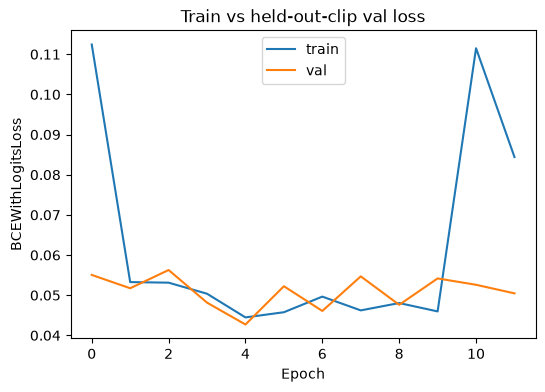

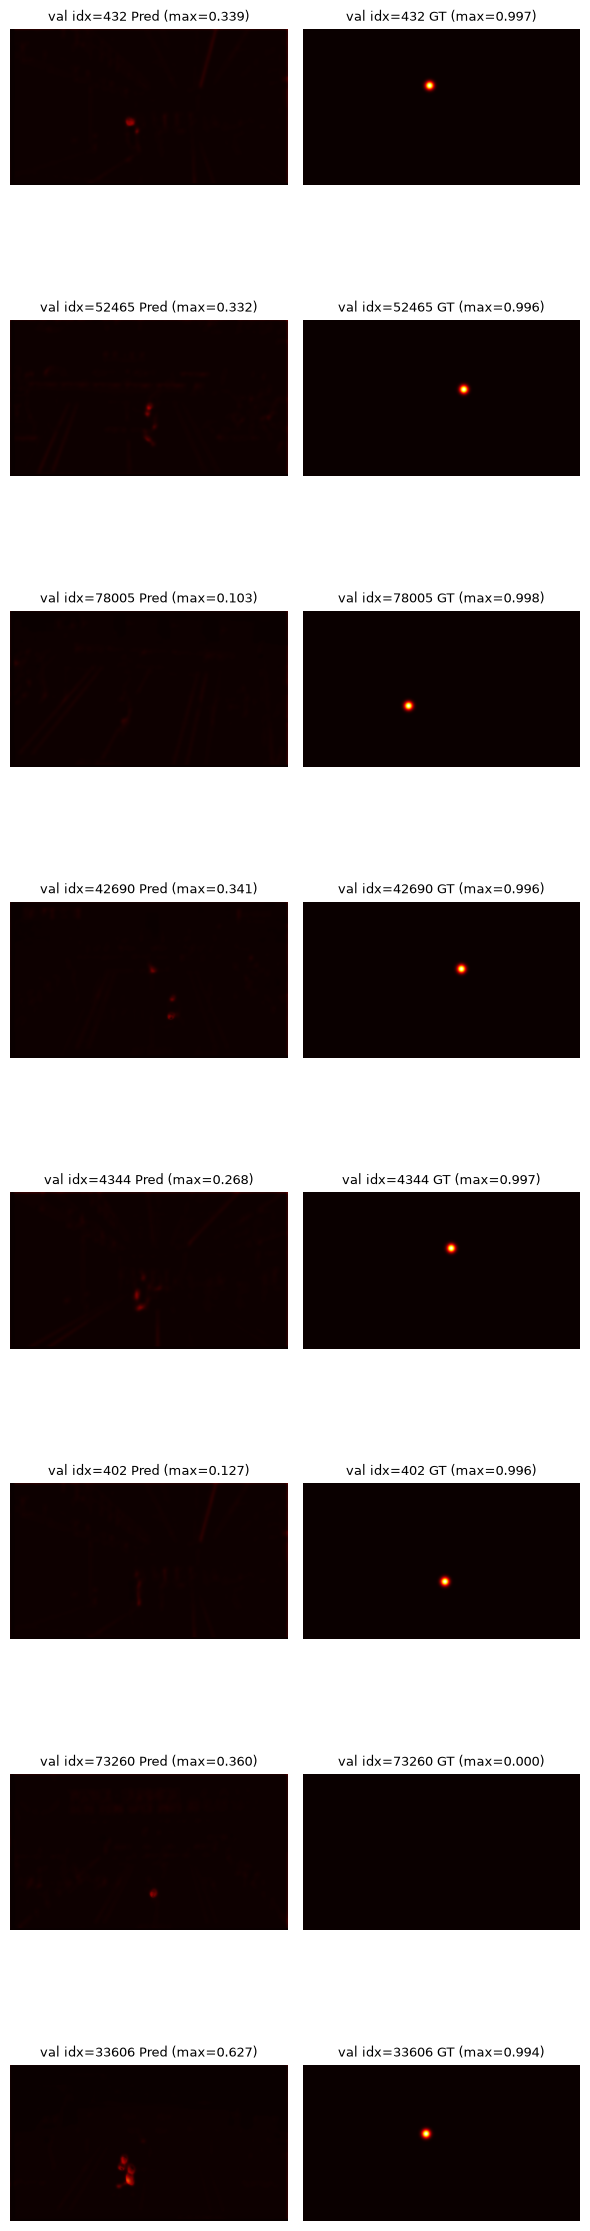

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.legend()
plt.title("Train vs held-out-clip val loss")
plt.show()

# Visualize predictions on held-out validation clips (never seen during training)
model.eval()
n_show = 8
show_indices = random.Random(123).sample(val_indices, min(n_show, len(val_indices)))
frame_idx = 1

fig, axes = plt.subplots(len(show_indices), 2, figsize=(6, len(show_indices) * 3))
with torch.no_grad():
    for row, idx in enumerate(show_indices):
        images, targets = heatmap_dataset[idx]
        images = images.unsqueeze(0).to(DEVICE)
        logits = model(images)
        preds = torch.sigmoid(logits)

        pred_heatmap = preds[0, frame_idx].cpu().numpy()
        target_heatmap = targets[frame_idx].numpy()

        axes[row, 0].imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        axes[row, 0].set_title(f"val idx={idx} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        axes[row, 1].set_title(f"val idx={idx} GT (max={target_heatmap.max():.3f})", fontsize=9)
        axes[row, 1].axis('off')

plt.tight_layout()
plt.show()